In [1]:
import pandas as pd
import numpy as np

In [18]:
df = pd.read_csv("/Users/jialin/Desktop/mit/Fall25/15.451 Proseminar in Capital Markets/mkt-regimes-pf-allocation/main_project/data/macro_final/final_macro.csv")
stock_df = pd.read_csv("/Users/jialin/Desktop/mit/Fall25/15.451 Proseminar in Capital Markets/mkt-regimes-pf-allocation/main_project/data/macro_processed/sp500_processed.csv")
bond_df = pd.read_csv("/Users/jialin/Desktop/mit/Fall25/15.451 Proseminar in Capital Markets/mkt-regimes-pf-allocation/main_project/data/macro_processed/3m_yield_processed.csv")

In [19]:
# Convert date columns to datetime if not already
df['date'] = pd.to_datetime(df['date'])
stock_df['date'] = pd.to_datetime(stock_df['date'])
bond_df['date'] = pd.to_datetime(bond_df['date'])

In [ ]:
# Filter to start from 1990-01-01
start_date = pd.to_datetime('1990-01-01')

df = df[df['date'] >= start_date].reset_index(drop=True)
stock_df = stock_df[stock_df['date'] >= start_date].reset_index(drop=True)
bond_df = bond_df[bond_df['date'] >= start_date].reset_index(drop=True)

print("All dataframes aligned to start from 1990-01-01")
print(f"\ndf shape: {df.shape}, start date: {df['date'].min()}")
print(f"stock_df shape: {stock_df.shape}, start date: {stock_df['date'].min()}")
print(f"bond_df shape: {bond_df.shape}, start date: {bond_df['date'].min()}")

All dataframes aligned to start from 1990-01-01

df shape: (432, 5), start date: 1990-01-01 00:00:00
stock_df shape: (431, 15), start date: 1990-01-31 00:00:00
bond_df shape: (8974, 10), start date: 1990-01-02 00:00:00


In [26]:
# Aggregate bond_df to monthly frequency

# Set date as index
bond_df = bond_df.set_index('date')

# Resample to monthly frequency (taking the last value of each month)
bond_df_monthly = bond_df.resample('ME').last()

# Reset index to have date as a column
bond_df_monthly = bond_df_monthly.reset_index()

print("Bond DF aggregated to monthly frequency")
print(f"\nOriginal bond_df shape: {bond_df.shape}")
print(f"Monthly bond_df shape: {bond_df_monthly.shape}")
print(f"Date range: {bond_df_monthly['date'].min()} to {bond_df_monthly['date'].max()}")
print(f"\nMonthly bond_df head:")
print(bond_df_monthly.head())

bond_df = bond_df_monthly

Bond DF aggregated to monthly frequency

Original bond_df shape: (431, 9)
Monthly bond_df shape: (431, 10)
Date range: 1990-01-31 00:00:00 to 2025-11-30 00:00:00

Monthly bond_df head:
        date  value  first_diff  pct_change_mom  pct_change_yoy  zscore_value  \
0 1990-01-31   8.00        0.00        0.000000        3.359173      2.281189   
1 1990-02-28   8.04        0.05        0.625782        0.249377      2.298696   
2 1990-03-31   8.07       -0.03       -0.370370       -1.944107      2.311826   
3 1990-04-30   8.07        0.02        0.248447        0.498132      2.311826   
4 1990-05-31   8.01       -0.02       -0.249066        1.520913      2.285566   

   zscore_first_diff  minmax_value  minmax_first_diff  minmax_pct_change_mom  
0           0.009326      0.968523           0.515924                    0.0  
1           1.087712      0.973366           0.547771                    0.0  
2          -0.637705      0.976998           0.496815                    0.0  
3           

In [33]:
bond_df.head()

,date,value,first_diff,pct_change_mom,pct_change_yoy,zscore_value,zscore_first_diff,minmax_value,minmax_first_diff,minmax_pct_change_mom
0,1990-01-31,8.00,0.00,0.000000,3.359173,2.281189,0.009326,0.968523,0.515924,0.0
1,1990-02-28,8.04,0.05,0.625782,0.249377,2.298696,1.087712,0.973366,0.547771,0.0
2,1990-03-31,8.07,-0.03,-0.370370,-1.944107,2.311826,-0.637705,0.976998,0.496815,0.0
3,1990-04-30,8.07,0.02,0.248447,0.498132,2.311826,0.440680,0.976998,0.528662,0.0
4,1990-05-31,8.01,-0.02,-0.249066,1.520913,2.285566,-0.422028,0.969734,0.503185,0.0


In [30]:
# STEP 2: Identify regimes for each time period using mode

# Define regime thresholds (using mode as cutoff)
growth_mode = df['growth_factor'].mode()[0]
inflation_mode = df['inflation_factor'].mode()[0]

print(f"Growth Mode: {growth_mode:.4f}")
print(f"Inflation Mode: {inflation_mode:.4f}")

# Classify into 4 regimes
def classify_regime(row):
    high_growth = row['growth_factor'] > growth_mode
    high_inflation = row['inflation_factor'] > inflation_mode
    
    if high_growth and high_inflation:
        return 'HG_HI'
    elif high_growth and not high_inflation:
        return 'HG_LI'
    elif not high_growth and high_inflation:
        return 'LG_HI'
    else:
        return 'LG_LI'

df['regime'] = df.apply(classify_regime, axis=1)

# Lag regime by 2 periods to remove forward bias
df['regime_lagged'] = df['regime'].shift(2)

print("\nStep 2 Complete: Regimes identified")
print(f"\nRegime Classification Summary:\n{df['regime'].value_counts()}")
print(f"\nRegime Lagged Classification Summary:\n{df['regime_lagged'].value_counts()}")

Growth Mode: 0.9460
Inflation Mode: 0.2647

Step 2 Complete: Regimes identified

Regime Classification Summary:
regime
LG_LI    230
LG_HI     88
HG_LI     76
HG_HI     38
Name: count, dtype: int64

Regime Lagged Classification Summary:
regime_lagged
LG_LI    228
LG_HI     88
HG_LI     76
HG_HI     38
Name: count, dtype: int64


In [34]:
# STEP 3: Construct regime-based portfolio trading strategy

# Define allocation strategy based on regimes
allocations = {
    'HG_HI': {'stocks': 0.60, 'bonds': 0.40},
    'HG_LI': {'stocks': 0.70, 'bonds': 0.30},
    'LG_HI': {'stocks': 0.35, 'bonds': 0.65},
    'LG_LI': {'stocks': 0.45, 'bonds': 0.55}
}

# Assign allocations based on LAGGED regime (T+2)
df['stock_allocation'] = df['regime_lagged'].map(lambda x: allocations[x]['stocks'] if pd.notna(x) else np.nan)
df['bond_allocation'] = df['regime_lagged'].map(lambda x: allocations[x]['bonds'] if pd.notna(x) else np.nan)

# Remove rows with NaN allocations
df_strategy = df.dropna(subset=['stock_allocation', 'bond_allocation']).copy()

# For each date in df (start of month), find the end of month date
df_strategy['end_of_month'] = df_strategy['date'] + pd.offsets.MonthEnd(0)

# Merge returns into strategy dataframe using end_of_month dates
df_strategy = df_strategy.merge(stock_df[['date', 'pct_change_mom']].rename(columns={'date': 'end_of_month', 'pct_change_mom': 'stock_return'}), on='end_of_month', how='left')
df_strategy = df_strategy.merge(bond_df[['date', 'first_diff']].rename(columns={'date': 'end_of_month', 'first_diff': 'bond_return'}), on='end_of_month', how='left')

# Remove any rows where returns are missing
df_strategy = df_strategy.dropna(subset=['stock_return', 'bond_return'])

# Calculate regime-based portfolio returns
df_strategy['regime_portfolio_return'] = (df_strategy['stock_allocation'] * df_strategy['stock_return'] + 
                                          df_strategy['bond_allocation'] * df_strategy['bond_return'])

# Calculate 50/50 benchmark portfolio returns
df_strategy['benchmark_return'] = 0.50 * df_strategy['stock_return'] + 0.50 * df_strategy['bond_return']

print("Step 3 Complete: Portfolio strategy constructed")
print(f"\nStrategy dataframe shape: {df_strategy.shape}")
print(f"\nAllocation by Regime:")
for regime, alloc in allocations.items():
    regime_count = (df_strategy['regime_lagged'] == regime).sum()
    print(f"  {regime}: {alloc['stocks']:.0%} stocks / {alloc['bonds']:.0%} bonds (n={regime_count})")
print(f"\nPortfolio returns head:")
print(df_strategy[['date', 'end_of_month', 'regime_lagged', 'stock_allocation', 'bond_allocation', 'stock_return', 'bond_return', 'regime_portfolio_return', 'benchmark_return']].head(10))

Step 3 Complete: Portfolio strategy constructed

Strategy dataframe shape: (302, 14)

Allocation by Regime:
  HG_HI: 60% stocks / 40% bonds (n=62)
  HG_LI: 70% stocks / 30% bonds (n=64)
  LG_HI: 35% stocks / 65% bonds (n=101)
  LG_LI: 45% stocks / 55% bonds (n=75)

Portfolio returns head:
         date end_of_month regime_lagged  stock_allocation  bond_allocation  \
1  1990-04-01   1990-04-30         HG_HI              0.60             0.40   
2  1990-05-01   1990-05-31         LG_HI              0.35             0.65   
4  1990-07-01   1990-07-31         LG_HI              0.35             0.65   
5  1990-08-01   1990-08-31         LG_HI              0.35             0.65   
7  1990-10-01   1990-10-31         LG_HI              0.35             0.65   
8  1990-11-01   1990-11-30         LG_HI              0.35             0.65   
9  1990-12-01   1990-12-31         LG_HI              0.35             0.65   
10 1991-01-01   1991-01-31         LG_LI              0.45             0.55   

In [35]:
 # STEP 4: Evaluate performance of regime-based strategy vs 50/50 benchmark

# Calculate cumulative returns
df_strategy['regime_cumulative_return'] = (1 + df_strategy['regime_portfolio_return']).cumprod()
df_strategy['benchmark_cumulative_return'] = (1 + df_strategy['benchmark_return']).cumprod()

# Performance metrics for regime-based strategy
regime_total_return = (df_strategy['regime_cumulative_return'].iloc[-1] - 1) * 100
regime_annual_return = df_strategy['regime_portfolio_return'].mean() * 12 * 100
regime_annual_vol = df_strategy['regime_portfolio_return'].std() * np.sqrt(12) * 100
regime_sharpe = (df_strategy['regime_portfolio_return'].mean() / df_strategy['regime_portfolio_return'].std()) * np.sqrt(12)

# Performance metrics for 50/50 benchmark
benchmark_total_return = (df_strategy['benchmark_cumulative_return'].iloc[-1] - 1) * 100
benchmark_annual_return = df_strategy['benchmark_return'].mean() * 12 * 100
benchmark_annual_vol = df_strategy['benchmark_return'].std() * np.sqrt(12) * 100
benchmark_sharpe = (df_strategy['benchmark_return'].mean() / df_strategy['benchmark_return'].std()) * np.sqrt(12)

print("Step 4 Complete: Performance evaluation")
print(f"\n{'='*70}")
print(f"REGIME-BASED STRATEGY PERFORMANCE")
print(f"{'='*70}")
print(f"Total Return: {regime_total_return:.2f}%")
print(f"Annual Return: {regime_annual_return:.2f}%")
print(f"Annual Volatility: {regime_annual_vol:.2f}%")
print(f"Sharpe Ratio: {regime_sharpe:.2f}")

print(f"\n{'='*70}")
print(f"50/50 BENCHMARK PERFORMANCE")
print(f"{'='*70}")
print(f"Total Return: {benchmark_total_return:.2f}%")
print(f"Annual Return: {benchmark_annual_return:.2f}%")
print(f"Annual Volatility: {benchmark_annual_vol:.2f}%")
print(f"Sharpe Ratio: {benchmark_sharpe:.2f}")

print(f"\n{'='*70}")
print(f"OUTPERFORMANCE")
print(f"{'='*70}")
print(f"Total Return Difference: {(regime_total_return - benchmark_total_return):.2f}%")
print(f"Annual Return Difference: {(regime_annual_return - benchmark_annual_return):.2f}%")
print(f"Volatility Difference: {(regime_annual_vol - benchmark_annual_vol):.2f}%")
print(f"Sharpe Ratio Difference: {(regime_sharpe - benchmark_sharpe):.2f}")

Step 4 Complete: Performance evaluation

REGIME-BASED STRATEGY PERFORMANCE
Total Return: -1381191866574551015606944252575341763989295901704192.00%
Annual Return: 544.48%
Annual Volatility: 749.97%
Sharpe Ratio: 0.73

50/50 BENCHMARK PERFORMANCE
Total Return: 2030370310698129275373627729352143273472294912.00%
Annual Return: 494.87%
Annual Volatility: 755.06%
Sharpe Ratio: 0.66

OUTPERFORMANCE
Total Return Difference: -1381193896944861688635153178433843679745975028547584.00%
Annual Return Difference: 49.61%
Volatility Difference: -5.08%
Sharpe Ratio Difference: 0.07


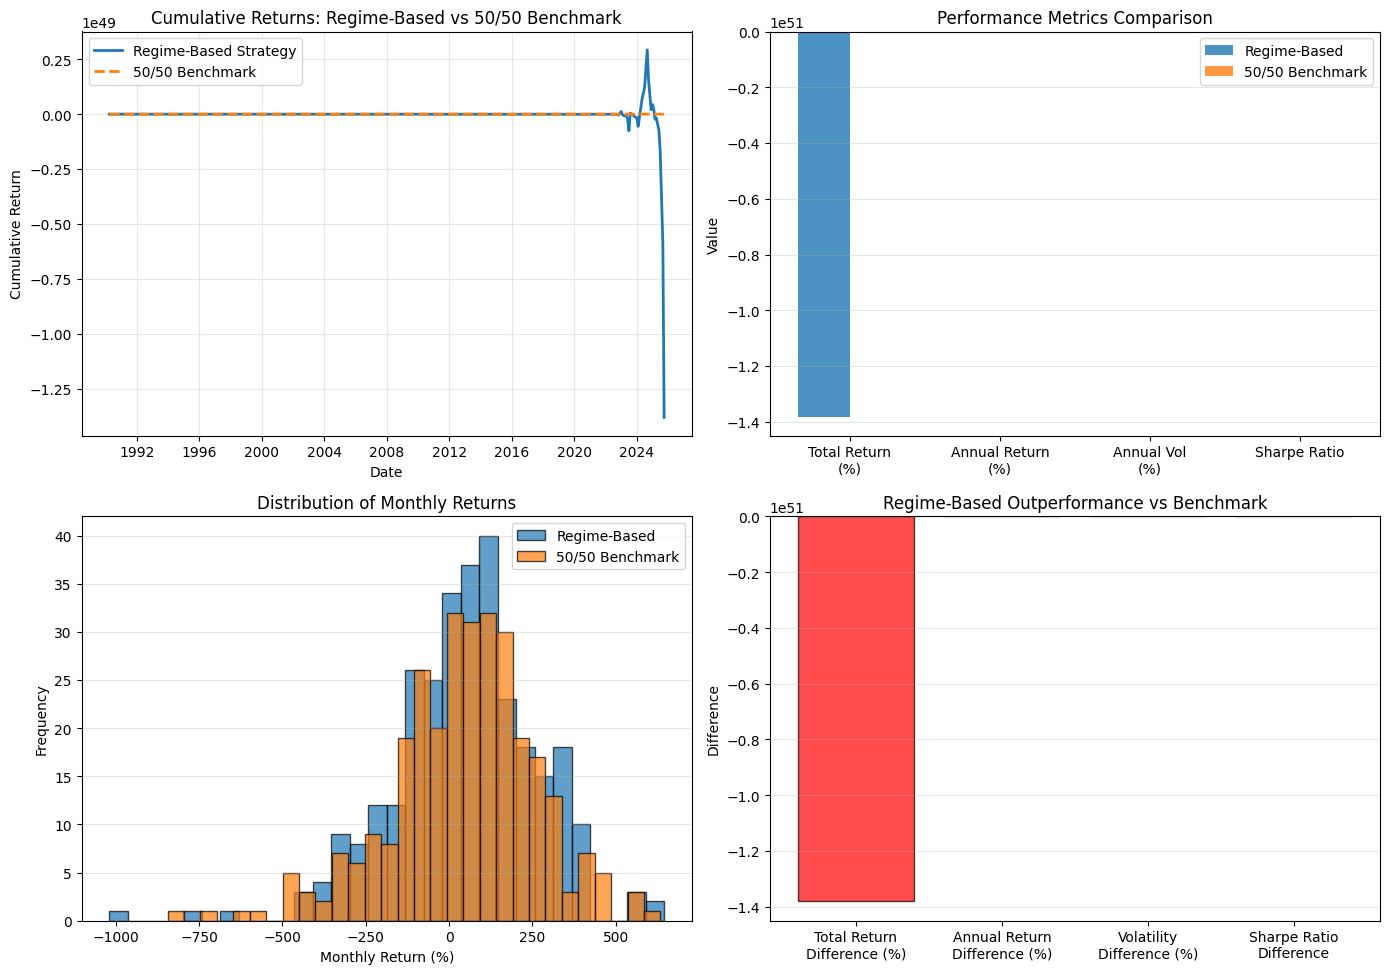


REGIME-BASED STRATEGY PERFORMANCE
Total Return: -1381191866574551015606944252575341763989295901704192.00%
Annual Return: 544.48%
Annual Volatility: 749.97%
Sharpe Ratio: 0.73

50/50 BENCHMARK PERFORMANCE
Total Return: 2030370310698129275373627729352143273472294912.00%
Annual Return: 494.87%
Annual Volatility: 755.06%
Sharpe Ratio: 0.66


In [36]:
# STEP 4: Visualize performance of regime-based strategy vs 50/50 benchmark

import matplotlib.pyplot as plt

# Calculate cumulative returns
df_strategy['regime_cumulative_return'] = (1 + df_strategy['regime_portfolio_return']).cumprod()
df_strategy['benchmark_cumulative_return'] = (1 + df_strategy['benchmark_return']).cumprod()

# Performance metrics for regime-based strategy
regime_total_return = (df_strategy['regime_cumulative_return'].iloc[-1] - 1) * 100
regime_annual_return = df_strategy['regime_portfolio_return'].mean() * 12 * 100
regime_annual_vol = df_strategy['regime_portfolio_return'].std() * np.sqrt(12) * 100
regime_sharpe = (df_strategy['regime_portfolio_return'].mean() / df_strategy['regime_portfolio_return'].std()) * np.sqrt(12)

# Performance metrics for 50/50 benchmark
benchmark_total_return = (df_strategy['benchmark_cumulative_return'].iloc[-1] - 1) * 100
benchmark_annual_return = df_strategy['benchmark_return'].mean() * 12 * 100
benchmark_annual_vol = df_strategy['benchmark_return'].std() * np.sqrt(12) * 100
benchmark_sharpe = (df_strategy['benchmark_return'].mean() / df_strategy['benchmark_return'].std()) * np.sqrt(12)

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Cumulative Returns Over Time
ax1 = axes[0, 0]
ax1.plot(df_strategy['date'], df_strategy['regime_cumulative_return'], label='Regime-Based Strategy', linewidth=2)
ax1.plot(df_strategy['date'], df_strategy['benchmark_cumulative_return'], label='50/50 Benchmark', linewidth=2, linestyle='--')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return')
ax1.set_title('Cumulative Returns: Regime-Based vs 50/50 Benchmark')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Performance Metrics Comparison
ax2 = axes[0, 1]
metrics = ['Total Return\n(%)', 'Annual Return\n(%)', 'Annual Vol\n(%)', 'Sharpe Ratio']
regime_values = [regime_total_return, regime_annual_return, regime_annual_vol, regime_sharpe]
benchmark_values = [benchmark_total_return, benchmark_annual_return, benchmark_annual_vol, benchmark_sharpe]

x = np.arange(len(metrics))
width = 0.35

ax2.bar(x - width/2, regime_values, width, label='Regime-Based', alpha=0.8)
ax2.bar(x + width/2, benchmark_values, width, label='50/50 Benchmark', alpha=0.8)
ax2.set_ylabel('Value')
ax2.set_title('Performance Metrics Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Monthly Returns Distribution
ax3 = axes[1, 0]
ax3.hist(df_strategy['regime_portfolio_return'] * 100, bins=30, alpha=0.7, label='Regime-Based', edgecolor='black')
ax3.hist(df_strategy['benchmark_return'] * 100, bins=30, alpha=0.7, label='50/50 Benchmark', edgecolor='black')
ax3.set_xlabel('Monthly Return (%)')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Monthly Returns')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Outperformance Metrics
ax4 = axes[1, 1]
outperformance_metrics = ['Total Return\nDifference (%)', 'Annual Return\nDifference (%)', 
                           'Volatility\nDifference (%)', 'Sharpe Ratio\nDifference']
outperformance_values = [
    regime_total_return - benchmark_total_return,
    regime_annual_return - benchmark_annual_return,
    regime_annual_vol - benchmark_annual_vol,
    regime_sharpe - benchmark_sharpe
]
colors = ['green' if v > 0 else 'red' for v in outperformance_values]

ax4.bar(outperformance_metrics, outperformance_values, color=colors, alpha=0.7, edgecolor='black')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax4.set_ylabel('Difference')
ax4.set_title('Regime-Based Outperformance vs Benchmark')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"REGIME-BASED STRATEGY PERFORMANCE")
print(f"{'='*70}")
print(f"Total Return: {regime_total_return:.2f}%")
print(f"Annual Return: {regime_annual_return:.2f}%")
print(f"Annual Volatility: {regime_annual_vol:.2f}%")
print(f"Sharpe Ratio: {regime_sharpe:.2f}")

print(f"\n{'='*70}")
print(f"50/50 BENCHMARK PERFORMANCE")
print(f"{'='*70}")
print(f"Total Return: {benchmark_total_return:.2f}%")
print(f"Annual Return: {benchmark_annual_return:.2f}%")
print(f"Annual Volatility: {benchmark_annual_vol:.2f}%")
print(f"Sharpe Ratio: {benchmark_sharpe:.2f}")